# Tutorial - Investment Optimization with GemsPy

## 1. Introduction to the study case

This tutorial explains how to handle **investment studies** in GEMS using the [GemsPy Python package](https://pypi.org/project/gemspy/).

We model a simple study case with:

- 1 **thermal plant** (with a capacity of 100 MW)
- 1 **renewable source** (time and scenario dependent)
- 1 **candidate thermal plant** (with a capacity to be assessed by the optimiser)
- 1 **load** (time and scenario dependent)

The optimiser finds the optimal capacity of the **candidate** plant to minimise total cost (investment + operational cost + unsupplied energy penalty).

### 1.1 Choice of the scenarios

We use **3 scenarios** and **168 timesteps**:

| Scenario | Load level | Renewable share | Without investment |
|---|---|---|---|
| **Scenario A** - Favourable | Low (55-70 MW) | High (5-60 MW) | No unsupplied energy |
| **Scenario B** - Critical | High (300-480 MW) | Low (5-20 MW) | 85-275 MW/h unsupplied energy |
| **Scenario C** - Intermediate | Medium (180-260 MW) | Medium (15-40 MW) | 0-45 MW/h unsupplied energy |


![Load](../../../assets/tuto_invest_load_demand_plot.png)

![Renewable](../../../assets/tuto_invest_renewable_generation_plot.png)

### 1.2 Study file structure

The study folder is inside the [`Tutorial_3_Investment/`](https://github.com/AntaresSimulatorTeam/GEMS/tree/main/doc/getting-started/tutorial-three-investment/tutorial_invest)

<details>
<summary><strong>Details of the <code>candidate_generator</code> model</strong></summary>

**parameters:**
- `investment_cost` - time and scenario independent, represents the initial investment cost
- `generation_cost` - time and scenario independent, represents the operational cost

**variables:**
- `p_installed` - the installed power capacity chosen by the optimiser; constant across time and scenarios, but *generation* will fluctuate
- `generation` - the actual power generation of the thermal candidate; cannot exceed `p_installed`

</details>

<details>
<summary><strong>⚠️ Warning - optim config file</strong></summary>

As we are running the study by GemsPy default **frontal** mode, we don't configure any `optim-config.yml` file.

Learn more about the GemsPy `optim-config.yml` file [in its documentation](https://gemspy.readthedocs.io/en/latest/user-guide/optim-config/).

</details>

## 2. Running the study
### 2.1 Installation of the required libraries

In [2]:
# Install required libraries
%pip install -r ../../../requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import warnings
warnings.filterwarnings("ignore")

### 2.2 Load and solve the study

In [3]:
from pathlib import Path
from gems.study.folder import load_study
from gems.session.session import SimulationSession
from gems.optim_config.parsing import OptimConfig, TimeScopeConfig, ScenarioScopeConfig

_cwd = Path.cwd()
study_dir_no_battery = _cwd / "tutorial_invest/case_no_battery"

print("STUDY LOADING")
study_no_battery = load_study(study_dir_no_battery)
print("\tStudy loaded")

optim_config = OptimConfig(
    time_scope=TimeScopeConfig(first_time_step=0, last_time_step=167),
    scenario_scope=ScenarioScopeConfig(nb_scenarios=3),
)

print("\nSOLVING OPTIMIZATION PROBLEM")
result = SimulationSession(study=study_no_battery, optim_config=optim_config).run()
print("\tOptimization problem solved")

STUDY LOADING
	Study loaded

SOLVING OPTIMIZATION PROBLEM


/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/model/resolve_library.py:139: UserWarning: Objective contribution 'objective' has a scenario dimension but no explicit expec() operator. Expectation semantics (average over scenarios) are applied automatically. Add expec() explicitly to suppress this warning.
  _resolve_model(m, current_lib.port_types, current_lib.id)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/model/resolve_library.py:139: UserWarning: Objective contribution 'expected_operating_cost' has a scenario dimension but no explicit expec() operator. Expectation semantics (average over scenarios) are applied automatically. Add expec() explicitly to suppress this warning.
  _resolve_model(m, current_lib.port_types, current_lib.id)


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
ERROR:   getOptionIndex: Option "solver_logs" is unknown
LP has 1512 rows; 2017 cols; 5040 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [3e-01, 3e+03]
  Bound   [1e+02, 1e+02]
  RHS     [5e-01, 5e+02]
Presolving model
1512 rows, 2017 cols, 5040 nonzeros 0s
804 rows, 1609 cols, 2412 nonzeros 0s
Dependent equations search running on 161 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
322 rows, 484 cols, 805 nonzeros 0s
Presolve reductions: rows 322(-1190); columns 484(-1533); nonzeros 805(-4235) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     1.2775966667e+05 Pr: 161(24228.5) 0.0s
        162     5.1798466667e+05 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal


/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/linopy/common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/linopy/common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


In [ ]:
obj_no_battery = float(result.data[result.data["output"] == "objective-value"]["value"].iloc[0])
print(f"Objective value: {obj_no_battery}")

## 3. Simple case without battery, thermal investment only 

### 3.1 Investment result: *p_installed*

The key output of an investment study is `p_installed` - the optimal capacity found by the optimiser. It is a **single value**, constant across all timesteps and scenarios, because the investment must be made before knowing which scenario will occur.

The optimiser sizes the candidate thermal plant to cover the worst-case demand across all scenarios and timesteps: the peak occurs in **Scenario B** where load reaches 482 MW with only 7 MW of renewable and 100 MW of existing thermal, leaving a residual of **375 MW** to be covered.

In [4]:
p_thermal_no_battery = result.component("candidate_thermal").output("p_installed").value().values.flat[0]

print("case_no_battery :")
print(f"candidate thermal - p_installed = {p_thermal_no_battery} MW")


case_no_battery :
candidate thermal - p_installed = 375.0 MW


/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_time] = filtered[col_time].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_scenario] = filtered[col_scenario].fillna(0)


### 3.2 Dispatch results

**Dispatch results** show how each asset is actually operated given the installed capacities - how much each unit generates at each timestep in each scenario. Unlike `p_installed`, these variables are **time and scenario dependent**: the same plant may run at full capacity in Scenario B and sit idle in Scenario A.

/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_time] = filtered[col_time].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_scenario] = filtered[col_scenario].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.p

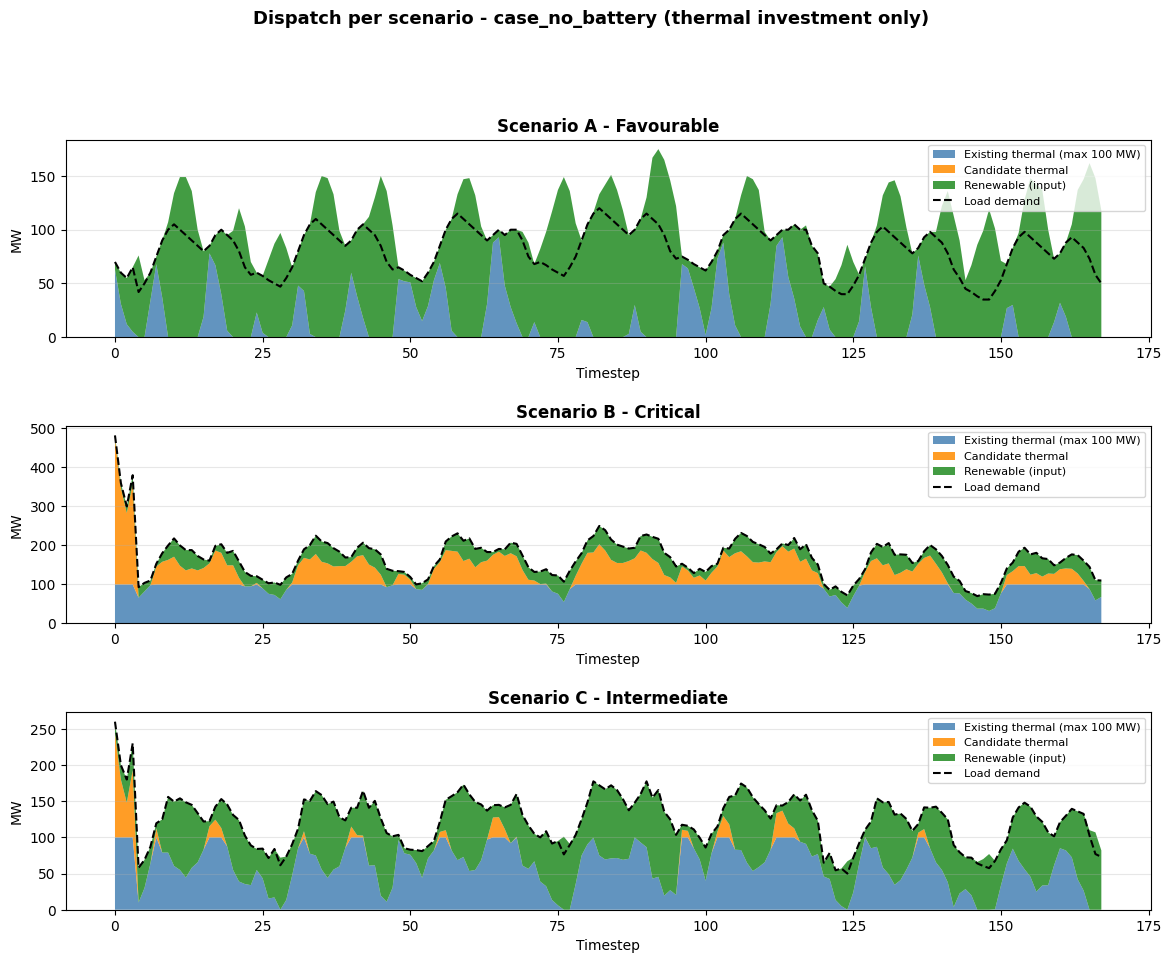

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io, base64
from IPython.display import display

renewable_data = np.loadtxt(study_dir_no_battery / "input/data-series/renewable_gen.txt")
load_data      = np.loadtxt(study_dir_no_battery / "input/data-series/load_demand.txt")

scenario_labels = ["Scenario A - Favourable", "Scenario B - Critical", "Scenario C - Intermediate"]
timesteps = list(range(168))
colors = ["steelblue", "darkorange", "forestgreen"]
stack_labels = ["Existing thermal (max 100 MW)", "Candidate thermal", "Renewable (input)"]

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 1, hspace=0.45)

for s, label in enumerate(scenario_labels):
    ax = fig.add_subplot(gs[s])

    existing_gen  = result.component("thermal_existing").output("generation").value(scenario_index=s).values
    candidate_gen = result.component("candidate_thermal").output("generation").value(scenario_index=s).values
    renewable_gen = renewable_data[timesteps, s]
    unsupplied    = result.component("node").output("unsupplied_energy").value(scenario_index=s).values
    load          = load_data[timesteps, s]

    ax.stackplot(timesteps, existing_gen, candidate_gen, renewable_gen,
                 labels=stack_labels, colors=colors, alpha=0.85)
    ax.plot(timesteps, load, "k--", linewidth=1.5, label="Load demand")

    if any(u > 0.1 for u in unsupplied):
        ax.plot(timesteps, unsupplied, "rv--", linewidth=1.5, markersize=6, label="Unsupplied energy")

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("MW")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Dispatch per scenario - case_no_battery (thermal investment only)", fontsize=13, fontweight="bold", y=1.01)

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
buf.seek(0)
display(
    {"image/png": base64.b64encode(buf.read()).decode()},
    raw=True,
    metadata={"image/png": {"alt": "Stacked area charts showing dispatch for each of the 3 scenarios across 168 timesteps, with load demand line."}}
)
plt.close(fig)


## 4. Additional investments case with a battery

We use the study folder case_with_battery to investigate the **battery investment** thanks to the [`storage_investment_candidate`](https://github.com/AntaresSimulatorTeam/GEMS/blob/main/doc/getting-started/tutorial-three-investment/tutorial_invest/case_with_battery/input/system.yml) model.

We use an investment cost up to 100€/MW.day, an efficiency of 92% and a storage for only 4 hours. The optimiser will find the optimal `p_installed` for this battery.

### 4.1 Loading and Solving the study

In [6]:
from pathlib import Path
from gems.study.folder import load_study
from gems.session.session import SimulationSession
from gems.optim_config.parsing import OptimConfig, TimeScopeConfig, ScenarioScopeConfig

_cwd = Path.cwd()
study_dir = _cwd / "tutorial_invest/case_with_battery"

print("STUDY LOADING")
study = load_study(study_dir)
print("\tStudy loaded")

optim_config = OptimConfig(
    time_scope=TimeScopeConfig(first_time_step=0, last_time_step=167),
    scenario_scope=ScenarioScopeConfig(nb_scenarios=3),
)

print("\nSOLVING OPTIMIZATION PROBLEM")
result = SimulationSession(study=study, optim_config=optim_config).run()
print("\tOptimization problem solved")

STUDY LOADING
	Study loaded

SOLVING OPTIMIZATION PROBLEM


/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/model/resolve_library.py:139: UserWarning: Objective contribution 'objective' has a scenario dimension but no explicit expec() operator. Expectation semantics (average over scenarios) are applied automatically. Add expec() explicitly to suppress this warning.
  _resolve_model(m, current_lib.port_types, current_lib.id)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/model/resolve_library.py:139: UserWarning: Objective contribution 'expected_operating_cost' has a scenario dimension but no explicit expec() operator. Expectation semantics (average over scenarios) are applied automatically. Add expec() explicitly to suppress this warning.
  _resolve_model(m, current_lib.port_types, current_lib.id)


Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms
ERROR:   getOptionIndex: Option "solver_logs" is unknown
LP has 4038 rows; 3530 cols; 14118 nonzeros
Coefficient ranges:
  Matrix  [9e-01, 4e+00]
  Cost    [3e-01, 3e+03]
  Bound   [1e+02, 1e+02]
  RHS     [5e-01, 5e+02]
Presolving model
4032 rows, 3527 cols, 14097 nonzeros 0s
3021 rows, 3527 cols, 9060 nonzeros 0s
Presolve reductions: rows 3021(-1017); columns 3527(-3); nonzeros 9060(-5058) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     6.2500249053e+03 Pr: 507(40982) 0.0s
       1363     4.9312414493e+05 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   iterations: 1363
Objective value     :  4.9312414493e+05
P-D objective error :  5.9019217060e-16
HiGHS run time      :          0.04
	Optimization problem solved


/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/linopy/common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/linopy/common.py:504: UserWarning: Coordinates across variables not equal. Perform outer join.
  warn(


In [ ]:
obj_with_battery = float(result.data[result.data["output"] == "objective-value"]["value"].iloc[0])
print(f"Objective value: {obj_with_battery}")

### 4.2 Investment results

Adding a battery investment option does **not reduce the required thermal capacity** in this case: the optimiser still installs **375 MW** of candidate thermal, identical to case_no_battery. It also invests **90 MW** of battery.

The reason is that the battery alone cannot substitute for firm thermal capacity during sustained peak demand in Scenario B: the peak load deficit (around 375 MW) exceeds what a 4-hour storage can cover without the thermal plant running at full output. The optimiser therefore keeps the same thermal capacity and adds the battery on top to reduce operating costs by charging from cheap renewable or off-peak periods and discharging at peak.

In [ ]:
p_thermal_with_battery = result.component("candidate_thermal").output("p_installed").value().values.flat[0]
p_battery_with_battery = result.component("storage_investment_candidate").output("p_installed").value().values.flat[0]
print("case_no_battery :")
print(f"candidate thermal - p_installed = {p_thermal_no_battery} MW")
print("case_with_battery :")
print(f"candidate thermal - p_installed = {p_thermal_with_battery} MW")
print(f"candidate battery - p_installed = {p_battery_with_battery} MW")

case_no_battery :
candidate thermal - p_installed = 375.0 MW
case_with_battery :
candidate thermal - p_installed = 375.0 MW
candidate battery - p_installed = 90.32999999999998 MW


/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_time] = filtered[col_time].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_scenario] = filtered[col_scenario].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.p

/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_time] = filtered[col_time].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.py:72: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered[col_scenario] = filtered[col_scenario].fillna(0)
/home/gmaistre/Documents/GEMS/GEMS/documentation_env/lib/python3.12/site-packages/gems/simulation/simulation_table.p

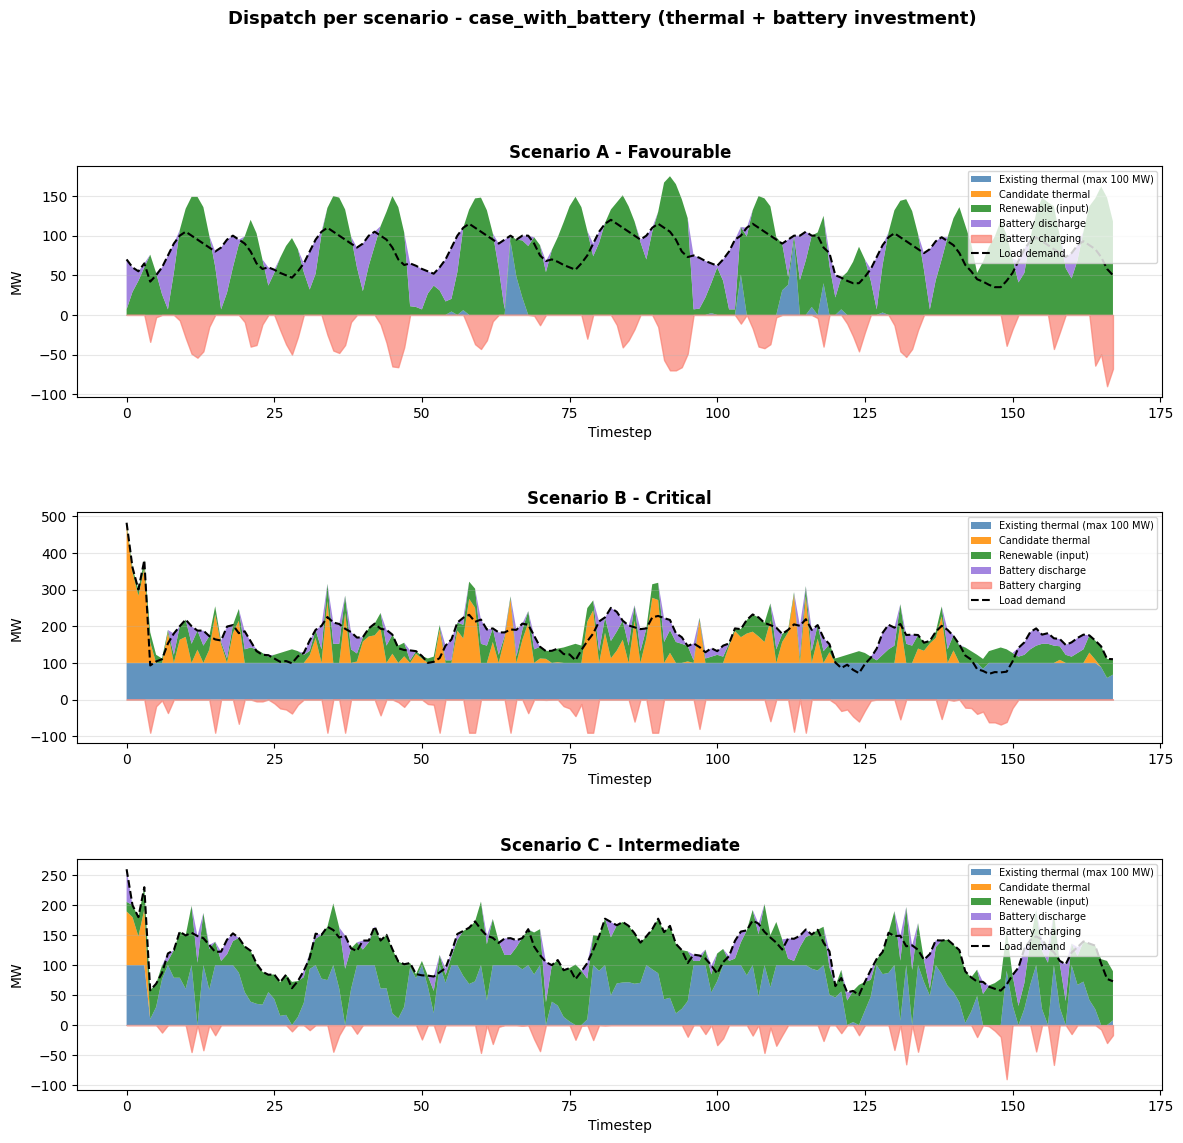

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import io, base64
from IPython.display import display

renewable_data = np.loadtxt(study_dir / "input/data-series/renewable_gen.txt")
load_data      = np.loadtxt(study_dir / "input/data-series/load_demand.txt")

scenario_labels = ["Scenario A - Favourable", "Scenario B - Critical", "Scenario C - Intermediate"]
timesteps = list(range(168))
colors      = ["steelblue", "darkorange", "forestgreen", "mediumpurple"]
stack_labels = ["Existing thermal (max 100 MW)", "Candidate thermal", "Renewable (input)", "Battery discharge"]

fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(3, 1, hspace=0.5)

for s, label in enumerate(scenario_labels):
    ax = fig.add_subplot(gs[s])

    existing_gen  = result.component("thermal_existing").output("generation").value(scenario_index=s).values
    candidate_gen = result.component("candidate_thermal").output("generation").value(scenario_index=s).values
    renewable_gen = renewable_data[timesteps, s]
    unsupplied    = result.component("node").output("unsupplied_energy").value(scenario_index=s).values
    load          = load_data[timesteps, s]
    p_withdrawal  = result.component("storage_investment_candidate").output("p_withdrawal").value(scenario_index=s).values
    p_injection   = result.component("storage_investment_candidate").output("p_injection").value(scenario_index=s).values

    ax.stackplot(timesteps, existing_gen, candidate_gen, renewable_gen, p_withdrawal,
                 labels=stack_labels, colors=colors, alpha=0.85)
    ax.fill_between(timesteps, -p_injection, 0, color="salmon", alpha=0.7, label="Battery charging")
    ax.plot(timesteps, load, "k--", linewidth=1.5, label="Load demand")

    if any(u > 0.1 for u in unsupplied):
        ax.plot(timesteps, unsupplied, "rv--", linewidth=1.5, markersize=6, label="Unsupplied energy")

    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Timestep")
    ax.set_ylabel("MW")
    lines1, labels1 = ax.get_legend_handles_labels()
    ax.legend(lines1, labels1, loc="upper right", fontsize=7)
    ax.grid(True, axis="y", alpha=0.3)

fig.suptitle("Dispatch per scenario - case_with_battery (thermal + battery investment)", fontsize=13, fontweight="bold", y=1.01)

buf = io.BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
buf.seek(0)
display(
    {"image/png": base64.b64encode(buf.read()).decode()},
    raw=True,
    metadata={"image/png": {"alt": "Stacked area charts with battery data for each of the 3 scenarios across 168 timesteps."}}
)
plt.close(fig)
